# Pipeline Analysis

## Data Preparation

In [63]:
import pandas as pd
import duckdb
import logging

# set up logging to track pipeline progress and catch errors
logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logging.info('Starting pipeline')

# load parquet files into DuckDB

try:
    # create a local DuckDB database file
    con = duckdb.connect('air_quality.db')
    logging.info('Connected to DuckDB')
    
    # drop and recreate all tables to avoid cached empty data
    con.execute("DROP TABLE IF EXISTS aqi")
    con.execute("DROP TABLE IF EXISTS no2")
    con.execute("DROP TABLE IF EXISTS ozone")
    con.execute("DROP TABLE IF EXISTS onroad")

    # register each parquet file as a table in the database
    con.execute("CREATE TABLE IF NOT EXISTS aqi AS SELECT * FROM read_parquet('daily_aqi_by_county_2020_2025.parquet')")
    con.execute("CREATE TABLE IF NOT EXISTS no2 AS SELECT * FROM read_parquet('daily_no2_by_county_2020_2025.parquet')")
    con.execute("CREATE TABLE IF NOT EXISTS ozone AS SELECT * FROM read_parquet('daily_ozone_by_county_2020_2025.parquet')")
    con.execute("CREATE TABLE IF NOT EXISTS onroad AS SELECT * FROM read_parquet('onroad_emissions_by_county_2020.parquet')")
    logging.info('All four tables loaded into DuckDB')

except Exception as e:
    logging.error(f'Error loading data into DuckDB: {e}')

print("AQI rows:", con.execute("SELECT COUNT(*) FROM aqi").df().values[0][0])
print("NO2 rows:", con.execute("SELECT COUNT(*) FROM no2").df().values[0][0])
print("Ozone rows:", con.execute("SELECT COUNT(*) FROM ozone").df().values[0][0])
print("Onroad rows:", con.execute("SELECT COUNT(*) FROM onroad").df().values[0][0])

AQI rows: 1843765
NO2 rows: 880459
Ozone rows: 2202126
Onroad rows: 4388194


## Queries + Master Data Cleaning

In [64]:
# 1. load and create target

# load AQI and create alert label (1 = unhealthy)
df = con.execute("""
    SELECT
        "State Code",
        "County Code",
        CAST("Date" AS DATE) AS Date,
        "AQI",
        CASE WHEN "AQI" >= 101 THEN 1 ELSE 0 END AS alert
    FROM aqi
""").df()



# 2. aggregate pollution data

# collapse NO2 to one row per county-day
no2_agg = con.execute("""
    SELECT
        "State Code",
        "County Code",
        CAST("Date Local" AS DATE) AS Date,
        AVG("Arithmetic Mean") AS no2_mean,
        MAX("1st Max Value") AS no2_max
    FROM no2
    GROUP BY 1,2,3
""").df()

# collapse ozone the same way
ozone_agg = con.execute("""
    SELECT
        "State Code",
        "County Code",
        CAST("Date Local" AS DATE) AS Date,
        AVG("Arithmetic Mean") AS ozone_mean,
        MAX("1st Max Value") AS ozone_max
    FROM ozone
    GROUP BY 1,2,3
""").df()



# 3. aggregate emissions data

# sum emissions per county (one row per county)
onroad_agg = con.execute("""
    SELECT
        CAST("fips code" AS BIGINT) AS fips,
        SUM("total emissions") AS total_onroad_emissions
    FROM onroad
    WHERE "fips code" IS NOT NULL
    GROUP BY 1
""").df()



# 4. merge datasets

# make sure keys are integers
for frame in [df, no2_agg, ozone_agg]:
    frame['State Code'] = frame['State Code'].astype(int)
    frame['County Code'] = frame['County Code'].astype(int)

# merge NO2 and ozone on county + date
df = df.merge(no2_agg, on=['State Code', 'County Code', 'Date'], how='left')
df = df.merge(ozone_agg, on=['State Code', 'County Code', 'Date'], how='left')

# create full FIPS code (state*1000 + county)
df['fips'] = df['State Code'] * 1000 + df['County Code']

# merge emissions correctly using FIPS
df = df.merge(onroad_agg, on='fips', how='left')


# 5. clean data

# remove rows with no pollution data
df = df.dropna(subset=['no2_mean', 'ozone_mean'])

# remove negative values from sensors
df[['no2_mean','no2_max','ozone_mean','ozone_max']] = df[
    ['no2_mean','no2_max','ozone_mean','ozone_max']
].clip(lower=0)

# remove unrealistic AQI outliers
df = df[df['AQI'] <= 500]

# fill missing emissions
df['total_onroad_emissions'] = df['total_onroad_emissions'].fillna(0)

## Solution Analysis - Random Forest Classification Model

In [65]:
# necessary imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

try:
    # choose the columns used as inputs and the column to predict
    features = ['no2_mean', 'no2_max', 'ozone_mean', 'ozone_max', 'total_onroad_emissions']
    target = 'alert'

    X = df[features]
    y = df[target]

    # print class balance to understand how rare alert days are
    print("Alert distribution:")
    print(y.value_counts())
    print(f"Alert rate: {y.mean():.2%}")

    # split data into train and test sets while keeping class proportions similar
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print(f"Training rows: {X_train.shape[0]}, Test rows: {X_test.shape[0]}")

    # create the random forest model with settings to reduce overfitting
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # train the model on the training data
    rf.fit(X_train, y_train)
    print("Model trained successfully")

    # generate predictions on unseen test data
    y_pred = rf.predict(X_test)

    # print precision, recall, and f1-score for both classes
    print("\nModel Performance:")
    print(classification_report(y_test, y_pred, target_names=['Safe', 'Alert']))

    # calculate how much each feature contributes to the model's decisions
    importances = pd.Series(
        rf.feature_importances_,
        index=features
    ).sort_values(ascending=False)

    print("\nFeature Importances:")
    print(importances)

except Exception as e:
    print(f"Error in model training: {e}")
    raise

Alert distribution:
alert
0    429915
1     12911
Name: count, dtype: int64
Alert rate: 2.92%
Training rows: 354260, Test rows: 88566
Model trained successfully

Model Performance:
              precision    recall  f1-score   support

        Safe       0.99      1.00      0.99     85984
       Alert       0.91      0.73      0.81      2582

    accuracy                           0.99     88566
   macro avg       0.95      0.87      0.90     88566
weighted avg       0.99      0.99      0.99     88566


Feature Importances:
ozone_max                 0.510809
ozone_mean                0.218952
total_onroad_emissions    0.116512
no2_max                   0.079105
no2_mean                  0.074621
dtype: float64


## Analysis Rationale
I chose a Random Forest classifier because it combines many decision trees to make predictions, which helps capture complex relationships between pollutants and air quality alerts. This approach works well for my data because it can handle large numbers of observations, different types of features, and nonlinear relationships between pollutants and alert days. Before modeling, I used DuckDB to query and aggregate AQI, NO2, ozone, and on-road emissions data at the county and daily level. These queries ensured that each county had a single row per day with average and maximum pollutant values, making it ready for the model. The model uses these features like NO2, ozone, and on-road emissions to predict whether a day will exceed the alert threshold. I limited the tree depth to 15 and required at least 5 samples per leaf to prevent overfitting to unusual data points. I also set class_weight to balanced because alert days are very rare, so the model gives them more importance. The results show high precision and recall for safe days and reasonable recall for alerts, meaning the model correctly identifies most alert days while avoiding too many false alarms. Feature importance indicates that ozone levels are the strongest drivers of alerts, followed by on-road emissions and NO2.

This model could help county-level governments issue timely air quality alerts to residents. By predicting alert days in advance, officials could warn sensitive populations and take preventive measures, like limiting outdoor activities or adjusting traffic regulations. The model can also identify which pollutants contribute most to unhealthy air days in each county, which helps prioritize mitigation strategies. Over time, the predictions could be integrated into a real-time monitoring system that combines sensor data and emissions information to provide more insights for public health planning. 

## Visualize Results

/var/folders/g7/cvzv0zcd5kq82hpk5dh_j9pr0000gn/T/ipykernel_28679/3772712358.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, ax=axes[0], palette="viridis")


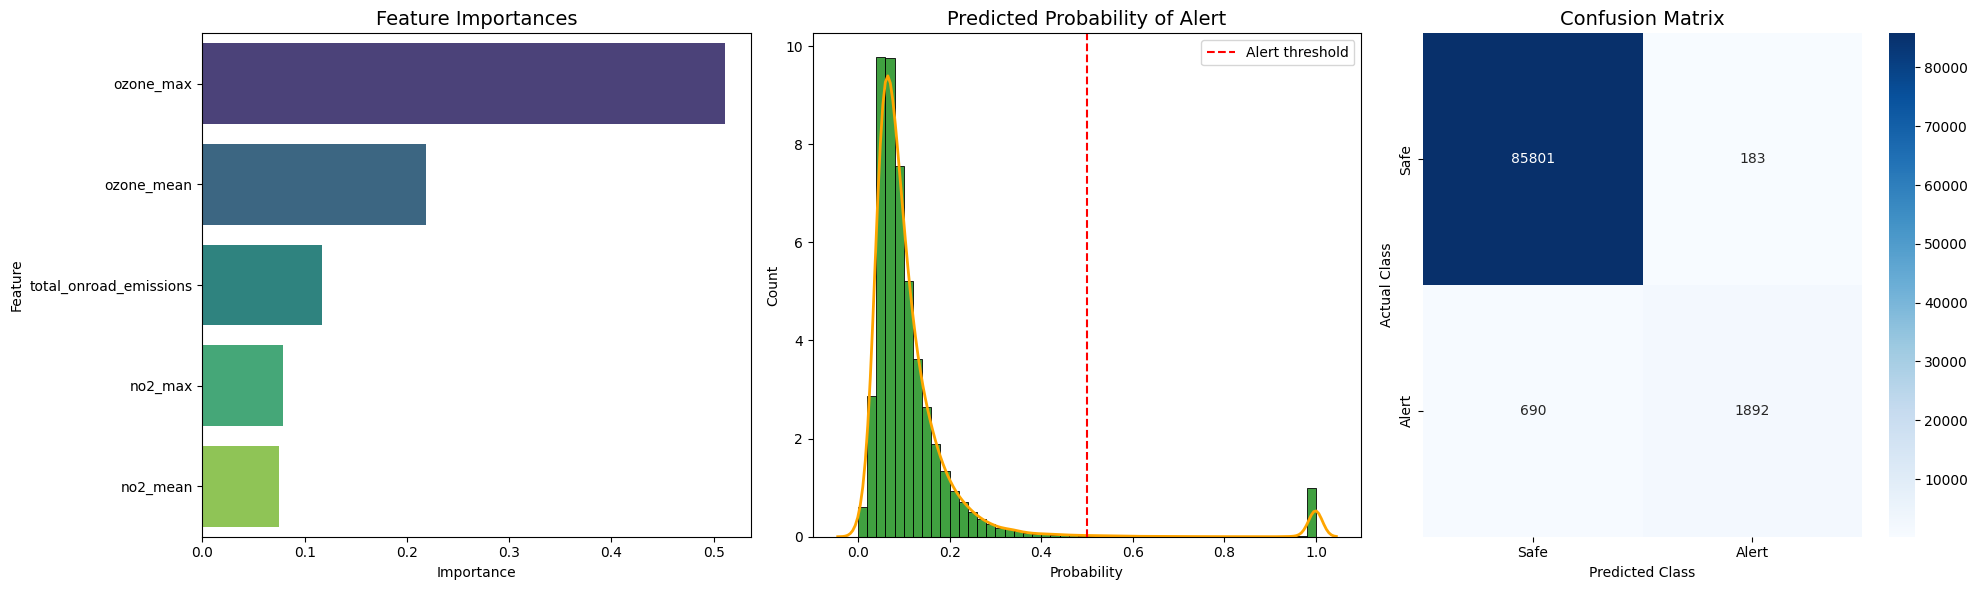

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# predicted probabilities for the positive class
y_prob = rf.predict_proba(X_test)[:, 1]

# feature importances
feat_importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_labels = ['Safe', 'Alert']

# creating a single figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# panel 1: Feature Importances
sns.barplot(x=feat_importances.values, y=feat_importances.index, ax=axes[0], palette="viridis")
axes[0].set_title('Feature Importances', fontsize=14)
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

# panel 2: Predicted Probability Distribution
sns.histplot(y_prob, bins=50, ax=axes[1], color='green', stat='density')
sns.kdeplot(y_prob, ax=axes[1], color='orange', linewidth=2)
axes[1].set_title('Predicted Probability of Alert', fontsize=14)
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Count')

# adding threshold line at 0.5 for high-risk classification
axes[1].axvline(0.5, color='red', linestyle='--', label='Alert threshold')
axes[1].legend()

# panel 3: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[2])
axes[2].set_title('Confusion Matrix', fontsize=14)
axes[2].set_xlabel('Predicted Class')
axes[2].set_ylabel('Actual Class')

plt.tight_layout()
plt.show()

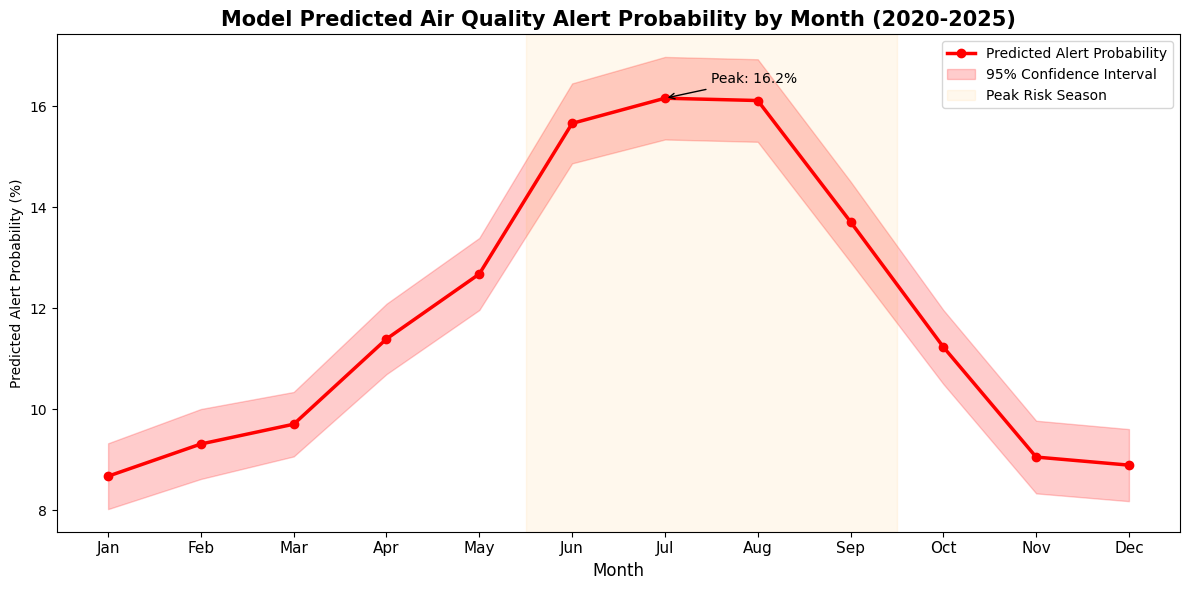

In [67]:
# add model predicted probability to the dataframe
df_test = X_test.copy()
df_test['alert_prob'] = rf.predict_proba(X_test)[:, 1]
df_test['month'] = pd.to_datetime(df.loc[X_test.index, 'Date']).dt.month

# calculate average predicted alert probability and confidence interval per month
monthly = df_test.groupby('month')['alert_prob'].agg(['mean', 'count']).reset_index()
monthly.columns = ['month', 'alert_rate', 'total_days']

# calculate 95% confidence interval using normal approximation
z = 1.96
monthly['se'] = np.sqrt((monthly['alert_rate'] * (1 - monthly['alert_rate'])) / monthly['total_days'])
monthly['ci_lower'] = (monthly['alert_rate'] - z * monthly['se']).clip(0)
monthly['ci_upper'] = monthly['alert_rate'] + z * monthly['se']

# month labels for x axis
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))

# plot the predicted alert probability line
ax.plot(monthly['month'], monthly['alert_rate'] * 100,
        color='red', linewidth=2.5, marker='o', markersize=6, label='Predicted Alert Probability')

# shade the confidence interval
ax.fill_between(monthly['month'],
                monthly['ci_lower'] * 100,
                monthly['ci_upper'] * 100,
                alpha=0.2, color='red', label='95% Confidence Interval')

# shade the summer peak risk season
ax.axvspan(5.5, 9.5, alpha=0.07, color='orange', label='Peak Risk Season')

# annotate the peak month
peak_month = monthly.loc[monthly['alert_rate'].idxmax(), 'month']
peak_rate = monthly.loc[monthly['alert_rate'].idxmax(), 'alert_rate'] * 100
ax.annotate(f'Peak: {peak_rate:.1f}%',
            xy=(peak_month, peak_rate),
            xytext=(peak_month + 0.5, peak_rate + 0.3),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))

# formatting
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=11)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Predicted Alert Probability (%)')
ax.set_title('Model Predicted Air Quality Alert Probability by Month (2020-2025)',
             fontsize=15, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## Visualization Rationale

I made two visualizations to communicate the model results clearly. The first is a three-panel figure showing feature importances, predicted alert probabilities, and a confusion matrix. Feature importances were shown as a horizontal bar chart because it makes it easy to compare which pollutants matter most at a glance. Ozone max came out as the strongest predictor, which matches what we know about summer air quality. The predicted probability distribution was included to show that the model is confident in most of its predictions, with probabilities clustering near 0 for safe days and near 1 for alert days. The confusion matrix was added to show exactly how many days the model got right and wrong, which is more informative than a single accuracy number.

The second visualization shows predicted alert probability by month with a 95% confidence interval. A line chart was chosen because it shows change over time clearly and the shaded band communicates uncertainty in a way that is easy to understand without a statistics background. The summer peak risk season is highlighted in yellow to draw attention to the months where government agencies would need to be most prepared. The peak annotation at July at 16.2% gives decision makers a specific number to plan around.